# 06. So sánh với thư viện

So sánh giá trị hàm mục tiêu và thời gian tính toán giữa mã tự viết và cài đặt
mặc định của scikit-learn.

Bước bắt buộc trước tiên là quy đổi hệ số hiệu chỉnh, vì mỗi thư viện dùng một
cách chuẩn hóa hàm mục tiêu khác nhau. Quy đổi được kiểm chứng bằng số, không suy
luận trên giấy.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src.plotting import set_style

set_style()


In [2]:
from src.baselines import (
    baselines_table,
    linear_regression_baseline,
    ridge_baseline,
    rmse,
    sgd_regressor_baseline,
    verify_conversions,
)
from src.data import load_problem, load_test_set
from src.runner import best_result, load_results

problem, config = load_problem()
X_test, y_test = load_test_set()

## Kiểm chứng quy đổi hàm mục tiêu

In [3]:
report = verify_conversions(problem)
for key, value in report.items():
    print(f"{key:>18s}: {value}")

assert report["passed"], "quy đổi alpha sai, mọi so sánh phía sau sẽ vô nghĩa"
print("\nRidge với solver trực tiếp tái tạo đúng nghiệm đóng.")

       alpha_ridge: 1600.0
         alpha_sgd: 0.01
    dist_to_w_star: 1.0647378311292136e-14
    relative_error: 1.362542662896795e-14
     objective_gap: 0.0
            passed: True

Ridge với solver trực tiếp tái tạo đúng nghiệm đóng.


## Chạy các baseline

In [4]:
records = [
    ridge_baseline(problem, solver="auto"),
    ridge_baseline(problem, solver="cholesky"),
    ridge_baseline(problem, solver="lsqr"),
    ridge_baseline(problem, solver="sag"),
    sgd_regressor_baseline(problem),
    linear_regression_baseline(problem),
]

table = baselines_table(records)
table["rmse_test"] = [rmse(problem, r["w"], X_test, y_test) for r in records]
table

,estimator,f,gap,grad_norm,time_s,dist_to_w_star,rmse_test
0,Ridge(solver='auto'),0.023743,0.000000e+00,9.806014e-14,0.111533,1.064738e-14,0.206014
1,Ridge(solver='cholesky'),0.023743,0.000000e+00,9.806014e-14,0.111899,1.064738e-14,0.206014
2,Ridge(solver='lsqr'),0.023743,2.349658e-09,5.763468e-05,0.580655,1.174546e-04,0.206014
3,Ridge(solver='sag'),0.023743,1.087108e-08,1.583435e-04,3.757813,1.430158e-04,0.206014
4,SGDRegressor (defaults),0.024906,1.163325e-03,5.073812e-02,1.015274,4.768342e-02,0.212017
5,LinearRegression,0.023778,3.481443e-05,7.902339e-03,1.094750,9.801016e-03,0.205794


## So sánh với mã tự viết

Các cài đặt thư viện không có lịch sử vòng lặp, nên chúng được vẽ thành điểm trên
mặt phẳng (thời gian, sai số hàm mục tiêu), đặt cạnh đường hội tụ của mã tự viết.

[PosixPath('/Users/huybq/Documents/work stuff/Optimization/results/figures/sklearn_time.pdf'),
 PosixPath('/Users/huybq/Documents/work stuff/Optimization/results/figures/sklearn_time.png')]

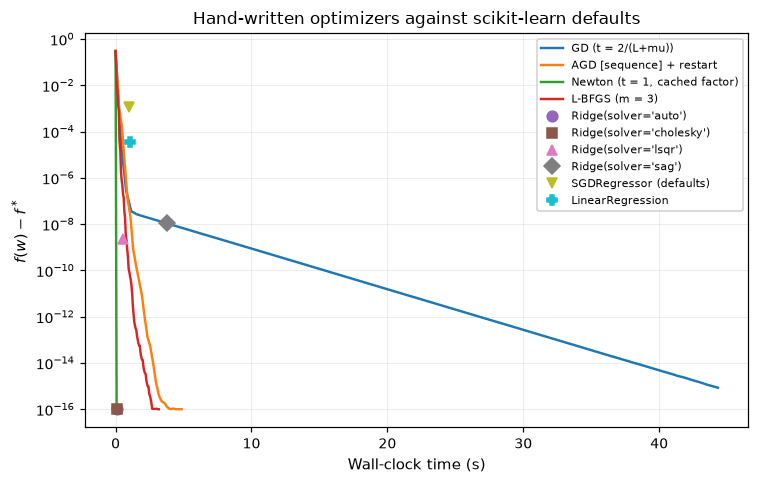

In [5]:
groups = {}
for name in ("gd_fixed", "agd", "newton", "lbfgs"):
    try:
        groups[name], _ = load_results(name)
    except FileNotFoundError:
        print(f"thiếu kết quả nhóm {name}")

best = [best_result(runs, problem.f_star) for runs in groups.values()]

FLOOR = 1e-16
fig, ax = plt.subplots(figsize=(7, 4.5))
for res in best:
    ax.semilogy(res.time_hist, res.suboptimality(problem.f_star, floor=FLOOR),
                label=res.params.get("label", res.method))

markers = ["o", "s", "^", "D", "v", "P"]
for record, marker in zip(records, markers):
    ax.semilogy([record["time_s"]], [max(record["gap"], FLOOR)], marker=marker,
                linestyle="none", markersize=7, label=record["label"])

ax.set_xlabel("Wall-clock time (s)")
ax.set_ylabel(r"$f(w) - f^*$")
ax.set_title("Hand-written optimizers against scikit-learn defaults")
ax.legend(fontsize=7, loc="best")
fig.tight_layout()

from src.plotting import save_figure
save_figure(fig, "sklearn_time")

[PosixPath('/Users/huybq/Documents/work stuff/Optimization/results/figures/sklearn_iter.pdf'),
 PosixPath('/Users/huybq/Documents/work stuff/Optimization/results/figures/sklearn_iter.png')]

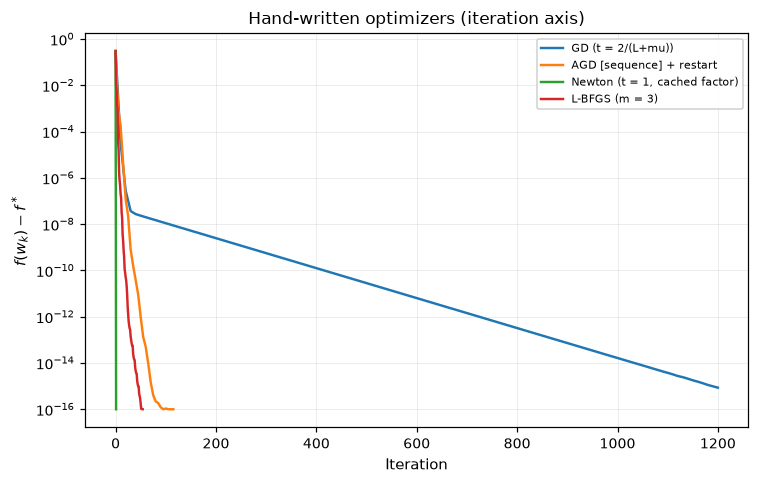

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for res in best:
    ax.semilogy(res.iter_hist, res.suboptimality(problem.f_star, floor=FLOOR),
                label=res.params.get("label", res.method))
ax.set_xlabel("Iteration")
ax.set_ylabel(r"$f(w_k) - f^*$")
ax.set_title("Hand-written optimizers (iteration axis)")
ax.legend(fontsize=7, loc="best")
fig.tight_layout()
save_figure(fig, "sklearn_iter")

## Ảnh hưởng của lambda tới tốc độ hội tụ

Thí nghiệm ở mục 5.6 của kế hoạch: tăng `lambda` làm tăng `mu`, giảm `kappa`, do
đó tăng tốc độ hội tụ. Bảng dưới đặt cạnh nhau tốc độ hội tụ và chất lượng dự báo
để thấy sự đánh đổi.

In [7]:
from src.first_order import gradient_descent
from src.problem import RidgeProblem

X_train = problem.X
y_train = problem.y
lam_values = [problem.lam * 0.1, problem.lam, problem.lam * 10]

rows, runs, labels = [], [], []
for lam in lam_values:
    p = RidgeProblem(X_train, y_train, lam)
    res = gradient_descent(
        p, max_iter=1200, record_every=10, step_rule={"kind": "fixed", "multiple": 1.0}
    )
    runs.append(res)
    labels.append(f"GD, lambda = {lam:.3g} (kappa = {p.kappa:.3g})")
    rows.append(
        {
            "lambda": lam,
            "mu": p.mu,
            "kappa": p.kappa,
            "iters_to_1e-6": res.iters_to_reach(p.f_star, 1e-6),
            "time_to_1e-6_s": res.time_to_reach(p.f_star, 1e-6),
            "rmse_test": rmse(p, p.w_star, X_test, y_test),
        }
    )
pd.DataFrame(rows)

,lambda,mu,kappa,iters_to_1e-6,time_to_1e-6_s,rmse_test
0,0.001,0.001,2674.086733,40,1.755940,0.205801
1,0.010,0.010,268.308673,40,1.771160,0.206014
2,0.100,0.100,27.730867,30,1.232972,0.219163


[PosixPath('/Users/huybq/Documents/work stuff/Optimization/results/figures/lambda_effect_iter.pdf'),
 PosixPath('/Users/huybq/Documents/work stuff/Optimization/results/figures/lambda_effect_iter.png')]

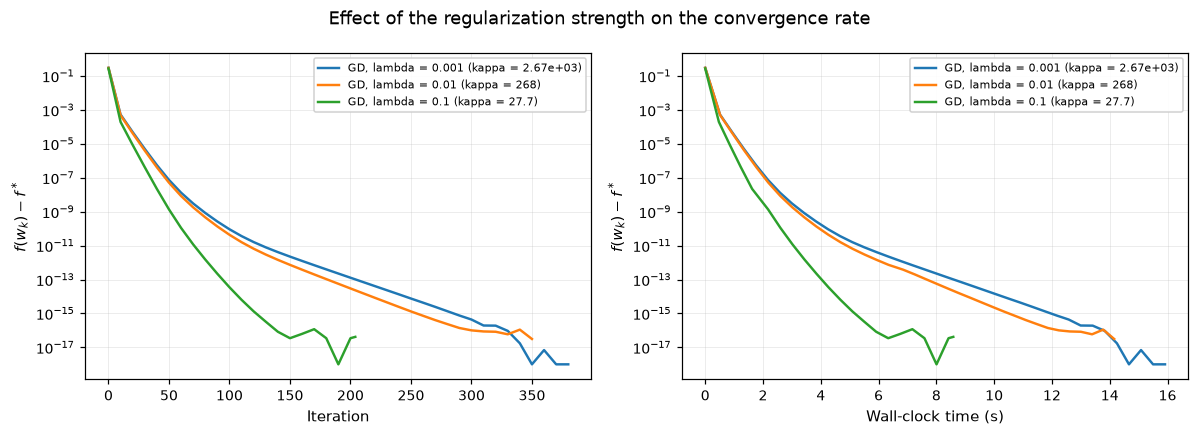

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for xaxis, ax in zip(("iter", "time"), axes):
    for lam, res, label in zip(lam_values, runs, labels):
        p = RidgeProblem(X_train, y_train, lam)
        x = res.iter_hist if xaxis == "iter" else res.time_hist
        ax.semilogy(x, res.suboptimality(p.f_star), label=label)
    ax.set_xlabel("Iteration" if xaxis == "iter" else "Wall-clock time (s)")
    ax.set_ylabel(r"$f(w_k) - f^*$")
    ax.legend(fontsize=7)
fig.suptitle("Effect of the regularization strength on the convergence rate")
fig.tight_layout()
save_figure(fig, "lambda_effect_iter")